Name + last 4 digits of ID:

# לירן ד 9397

# Computer Vision Classification Model - The notMNIST Dataset 

# Sources:
***
## Assistance
* **Google Gemini** - https://gemini.google.com/app?utm_source=app_launcher&utm_medium=owned&utm_campaign=base_all
* **Stack Overflow** - https://stackoverflow.com/questions
* ***
## Knowlendge and Theory

#### General Image Proccesing videos:
*  **Autonise on Youtube** - https://youtu.be/bI2raX05vlY?si=r_G89Lrs5ybh0D72
*  **Rob Mulla on Youtube** - https://www.youtube.com/watch?v=kSqxn6zGE0c
#### Image Proccesing using Pillow Library
* **Code Bear on Youtube** - https://www.youtube.com/playlist?list=PLH42YHDxfBrKnEd3n6JGdWScU01a6FCyI
#### KNN matematical theory and implementation:
* **NeuralNine on Youtube** - https://youtu.be/xtaom__-drE?si=EFJ3EGfB8WCXZFMr
#### Documentations
* **Pillow: Image module** - https://pillow.readthedocs.io/en/stable/reference/Image.html
* **Matplotlib** - https://matplotlib.org/stable/api/index.html
* **Numpy** - https://numpy.org/doc/stable/reference/index.html#reference

***
# The Machine Learning Problem and the Dataset
***
We are given a dataset containing 18,726 images of the first 10 capital letters of the alphabeit: A,B,C,D,E,F,G,H,I,J
#### **Our Task**:
**Create and Train a Classifying Machine Learning model that given a certain image, predicts which letter it fits from the ones above.**

For example:

If we give the model the following Image: (Which also happens to be the logo for a familiar Programming language)

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/18/C_Programming_Language.svg/500px-C_Programming_Language.svg.png" width="200" height="200">
Our desire is That the model we train will classify this image as the letter C
    
**This is a Multiclass classification Problem**

In [15]:
# For image load and manipulation:
import os
from PIL import Image

# For data storage & manipulation
import numpy as np

# For Image printing 
import matplotlib.pyplot as plt

# For analyzing and visualizing different experiments after Grid Search
import pandas as pd
import seaborn as sns

In [16]:
# A function that returns all the images in a certain path along with their corresponding labels
def load_images_from_folder(base_path, img_size):
    images = []
    labels = []

    label_dict = {
        "A": 0, "B": 1, "C": 2, "D": 3, "E": 4,
        "F": 5, "G": 6, "H": 7, "I": 8, "J": 9
    }

    # for each folder in the path provided (so for: 'A' folder, 'B' folder, 'C' folder, ..., 'J' folder)
    for folder in os.listdir(base_path):
        sub_folder = os.path.join(base_path, folder)
        label = label_dict[folder] # determine the label based on the the folder name
        # for each image in the current folder (for all the 'A' images, for all the 'B' images, ..., for all the 'J' images)
        for filename in os.listdir(sub_folder):
            try:
                # Open the image and add it to our list of images, also add it's corresponding label to our list of labels
                img = Image.open(os.path.join(sub_folder, filename)).convert("L")
                img = img.resize(img_size)
                img = np.array(img)
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {filename}: {e}")
                continue
    # return the lists as numpy arrays
    return np.array(images, dtype = "float64"), np.array(labels)

In [17]:
base_dir = "C:/Users/liran/Desktop/notMNIST"

#           0    1    2    3    4    5    6    7    8    9
classes = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']


IMG_SIZE = (28,28)

# Load our dataset, X holds the images and y holds their labels
X, y = load_images_from_folder(base_dir, img_size = IMG_SIZE)

Error loading RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png: cannot identify image file 'C:/Users/liran/Desktop/notMNIST\\A\\RGVtb2NyYXRpY2FCb2xkT2xkc3R5bGUgQm9sZC50dGY=.png'
Error loading Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png: cannot identify image file 'C:/Users/liran/Desktop/notMNIST\\F\\Q3Jvc3NvdmVyIEJvbGRPYmxpcXVlLnR0Zg==.png'


In [18]:
# The dataset is organized, we want to shuffle it to Prevent overfiting, for example when we use K-fold Cross Validation* later
# Note: If we wouldn't shuffle the dataset, Cross validation could fold the data in a way only certain letters are trained or some
# are trained more than others depending on their locations in the array. This step is crucial to prevent that
def shuffle_dataset(X, y):
    randomize = np.arange(X.shape[0])
    np.random.shuffle(randomize)
    X = X[randomize]
    y = y[randomize]
    return X, y

In [19]:
X,y = shuffle_dataset(X,y)

# Once the dataset is shuffled we can split the first 80% of the dataset for training, and the remaining 20% for testing
split_portion = int(len(X) * 0.8)
X_train, y_train = X[:split_portion], y[:split_portion]
X_test, y_test = X[split_portion:], y[split_portion:]

In [20]:
print(X_train[0])
print(f"Train set shape: {X_train.shape}") # 14630 entries with size (28,28)
print(f"Test set shape: {X_test.shape}") # 1500 entries with size (28,28)

[[  0.   0.   0.   0.   0.   2.   2.   0.   0.  27.  91. 184. 249. 255.
  255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 253. 255. 197.]
 [  0.   0.   0.   0.   3.   0.   0.  64. 159. 233. 255. 255. 255. 255.
  255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 253. 255. 197.]
 [  0.   0.   0.   3.   0.  37. 168. 255. 255. 255. 254. 253. 255. 255.
  255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 253. 255. 197.]
 [  0.   0.   4.   0.  78. 237. 255. 253. 252. 254. 255. 255. 255. 255.
  255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 253. 255. 197.]
 [  0.   3.   0.  92. 253. 255. 251. 255. 255. 255. 255. 255. 255. 255.
  255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 253. 255. 197.]
 [  3.   0.  55. 248. 254. 253. 255. 255. 255. 255. 255. 255. 255. 255.
  255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 255. 253. 255. 197.]
 [  1.   7. 216. 255. 252. 255. 255. 255. 255. 255. 255. 255. 255. 255.
  254. 253. 252. 251. 251. 251. 251. 251. 251. 251. 251. 2

## Let's observe some of the images in our dataset


Here are 5 samples from the training set:


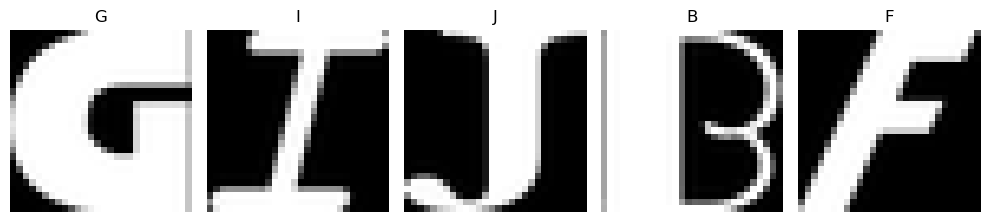

Here are 5 samples from the testing set:


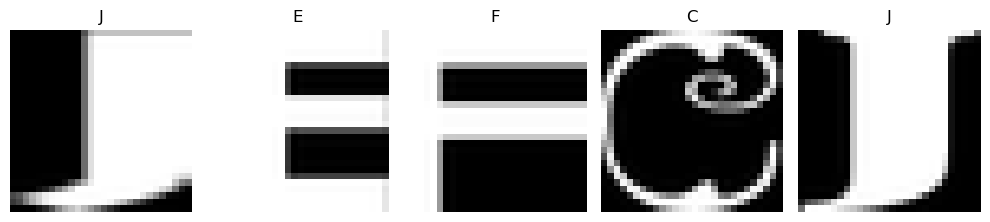

In [21]:
def show_images(dataset, label):
    num_samples = len(dataset)
    plt.figure(figsize=(10,10))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i+1)
        plt.imshow(dataset[i], cmap = "gray")
        plt.title(classes[label[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

NUM_SAMPLES = 5
print(f"Here are {NUM_SAMPLES} samples from the training set:")
show_images(X_train[:NUM_SAMPLES], y_train[:NUM_SAMPLES])
print(f"Here are {NUM_SAMPLES} samples from the testing set:")
show_images(X_test[:NUM_SAMPLES], y_test[:NUM_SAMPLES])

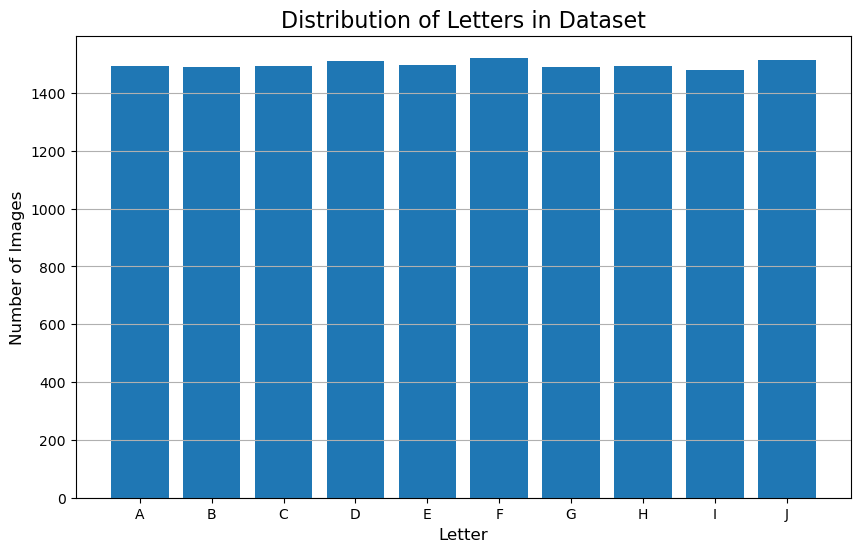

In [22]:
def plot_class_distribution(y, classes):
    counts = np.zeros(len(classes))
    for i in range(len(y)):
        counts[y[i]] += 1
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(classes, counts)

    plt.title('Distribution of Letters in Dataset', fontsize=16)
    plt.xlabel('Letter', fontsize=12)
    plt.ylabel('Number of Images', fontsize=12)
    plt.xticks(ticks=range(len(classes)), labels=classes)
    
    plt.grid(axis='y')
    plt.show()

plot_class_distribution(y_train, classes)

### As we can see our dataset is fairly balanced. Amounts differ between letters at 100 max as it seems

In [23]:
def normalize_dataset(X_train, X_test):
    # Our dataset is a list of matrixes (each image is a matrix of 28x28 pixels and we gather the images as a list), 
    # For further calculations by the model we'll train we must flatten the dataset. 
    # Meaning each image now becomes a 1D list of 28*28=784 pixels rather than a 2D matrix with size 28x28.
    
    X_train /= 255.0 # MIN-MAX Normalization
    X_test /= 255.0 # MIN-MAX Normalization
    X_train = X_train.reshape(X_train.shape[0], -1)
    X_test = X_test.reshape(X_test.shape[0], -1)
    return X_train, X_test

X_train, X_test = normalize_dataset(X_train, X_test)

In [24]:
class KNN_Image_Classifier:
    def __init__(self, k=5, metric = "euclidean"):
        self.k = k
        self.metric = metric
        self.X_train = None
        self.y_train = None

    def get_distances(self, v1, v2):
        if self.metric == "euclidean":
            distances = np.sqrt(np.sum((v1-v2) ** 2, axis = 1))
        elif self.metric == "manhattan":
            distances = np.sum(np.abs(v1-v2), axis = 1)
        elif self.metric == "chebyshev":
            distances = np.max(np.abs(v1-v2), axis = 1)
        else: # self.metric == "cosine"
            cos_thetas = (v1 @ v2) / (self.X_train_norm * np.linalg.norm(v2))     
            # When cos(theta) approaches -1, vectors are facing opposite directions (theta approaches 180), very low similarity, we want to punish that
            # When cos(theta) approaches 0, vectors are orthogonal (theta approaches 90), low similarity
            # When cos(theta) approaches 1, vectors are in the same direction (theta approaches 0), high similarity, we want to reward that
            # Therefore, the BIGGER cos(theta) is, the HIGHER the reward/similarity is. Meaning that the MINIMUM distance is contradictory to cos(theta)
            # So we take the OPPOSITE of cos(theta):
            distances = 1 - cos_thetas
        return distances

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        if self.metric == "cosine":
            self.X_train_norm = np.linalg.norm(X)

    
    def get_weights(self, k_nearest_distances, k_nearest_labels):
        scores = np.zeros(len(classes))
        weights = 1.0 / (k_nearest_distances + 1e-5)
        for label, weight in zip(k_nearest_labels, weights):
            scores[label] += weight
        return scores

    def predict(self, X_test):
        predictions = []
        if self.metric not in ["euclidean", "manhattan", "chebyshev", "cosine"]:
            print(f"DISTANCE METRIC '{self.metric}' IS INVALID")
            return None
        for x_img in X_test:
            distances = self.get_distances(self.X_train, x_img)
            sorted_k_indices = np.argsort(distances)[:self.k]
            k_nearest_distances = distances[sorted_k_indices]
            k_nearest_labels = self.y_train[sorted_k_indices]

            k_neighbors_scores = self.get_weights(k_nearest_distances, k_nearest_labels)
            predictions.append(np.argmax(k_neighbors_scores))
        return np.array(predictions)

## Calculating the Model's Macro f1 Score: (Using numpy only)
***
To calculate the macro f1 score of our model, we have to calculate the f1 score for each class from A to J, then Take the average score.

To calculate a single f1 score we have to calculate the precision and the recall

For that we must count the True Positives, the total Trues and the total Positives of each class;

Then get the precision by TP / total_Positives and get the recall by TP / total_Trues;

Only then we perform a harmonic average between precision and recall to achieve the f1 score of a single class.

Once we done that for every class we can return the average f1 score 

In [25]:
def calculate_f1_scores(y_pred, y_actual, classes):
    LETTERS_AMOUNT = len(classes)
    True_Positives = np.zeros(LETTERS_AMOUNT)
    Total_Trues = np.zeros(LETTERS_AMOUNT)
    Total_Positives = np.zeros(LETTERS_AMOUNT)
    f1_scores = []
    
    for i in range(len(y_actual)):
       # print(f"Pred: {letters[y_pred[i]]} ; Actual: {letters[y_actual[i]]}")
        Total_Trues[y_actual[i]] += 1
        Total_Positives[y_pred[i]] += 1
        if y_pred[i] == y_actual[i]:
            True_Positives[y_actual[i]] += 1
    precisions = np.zeros(LETTERS_AMOUNT)
    recalls = np.zeros(LETTERS_AMOUNT)
    for i in range(LETTERS_AMOUNT):
        if Total_Positives[i] > 0:
            precisions[i] = True_Positives[i] / Total_Positives[i]
        if Total_Trues[i] > 0:
            recalls[i] = True_Positives[i] / Total_Trues[i]
    
    f1_scores = []
    for i in range(LETTERS_AMOUNT):
        if precisions[i] + recalls[i] > 0:
            f1 = 2 * precisions[i] * recalls[i] / (precisions[i] + recalls[i])
            f1_scores.append(f1)
    return f1_scores

## Implementing Cross Validation
***
With the K-fold Cross Validation technique we are able to train K different models using only our training dataset.
We use two indexes, 'validation_start' and 'validation_end'. That way we can implement a sliding window who's size is 1/K of the entire training dataset.
By sliding this window we can extract 1/K of the data as a validation set, and the remaining (K-1)/K portion of the data becomes the training set.

So for example, if K=5 the split becomes 1/5 for validation and 4/5 for training, or 20%:80% alternatively.
The dataset is already randomized so we don't have to worry about the specific indexes of the images we take. We can just slide the window continuously from start to finish

The function 'split_dataset' uses an 'iteration' value that determines where to locate the sliding window. We place the window at the beggining of the list (iteration = 0) and we increment the iteration with every call to the function to move the window forward. When the window is out of bounds (iteration = k) we reset the iterator back to 0

In [26]:
class K_Fold_Cross_Validation:
    def __init__(self, dataset, label, k=5):
        self.k = k
        self.iteration = 0
        self.dataset = dataset
        self.label = label
        
    def split_dataset(self):
        # The size of the window
        window_length = len(self.dataset) // self.k
        
        # Window boundaries
        validation_start, validation_end = self.iteration * window_length, (self.iteration + 1)* window_length

        # Collect all data within the window (1/k for validation)
        X_validation = self.dataset[validation_start:validation_end]
        y_validation = self.label[validation_start:validation_end]

        # Collect all data outside the window ( (k-1)/k for training)
        X_train = np.concatenate((self.dataset[:validation_start], self.dataset[validation_end:]))
        y_train = np.concatenate((self.label[:validation_start], self.label[validation_end:]))

        self.iteration = (self.iteration + 1) % self.k
        return X_train, y_train, X_validation, y_validation

## Implementing Grid Search
***
With the Grid Search technique we are able to create multipule models with different parameters.

That way we can pick the parameters that satisfy the highest evaluation score possible. 
In our case with the KNN algorithm, we test different values of K (amount of neighbors) along with different values for the distance metric.

So if we test all the models from the Cartesian product: {3,5,7,9,11}X{"euclidean", "manhattan", "chebyshev", "cosine"}
Then our goal is to find the best pair of (k, metric); The one that leads to the highest Macro F1 Score

We combine Grid Search and Cross Validation together to get the best outcome

In [27]:
def grid_search(X_train, y_train, k_values, metrics):
    best_macro_f1, macro_f1_scores = 0, []
    best_params, params = {}, {"k": [], "metric": []}

    k_folds = 5
    cross_validator = K_Fold_Cross_Validation(X_train, y_train, k_folds)
    
    for k in k_values:
        for metric in metrics:
            params["k"].append(k)
            params["metric"].append(metric)
            print(f"Testing model for k={k} , metric={metric}...")
            current_combination_folds_scores = []
            for i in range(k_folds):
                X_fold_train, y_fold_train, X_fold_validation, y_fold_validation = cross_validator.split_dataset()
                model = KNN_Image_Classifier(k, metric)
                model.fit(X_fold_train, y_fold_train)
                y_pred = model.predict(X_fold_validation)
                
                f1_fold_scores = calculate_f1_scores(y_pred, y_fold_validation, classes)
                current_combination_folds_scores.append(np.mean(f1_fold_scores))
            
            macro_f1 = np.mean(current_combination_folds_scores)
            macro_f1_scores.append(macro_f1)
            if macro_f1 > best_macro_f1:
                best_macro_f1 = macro_f1
                best_params = {"k":k, "metric":metric}
                
    return params, best_params, macro_f1_scores, best_macro_f1

In [28]:
k_values = [3,5,7,9,11]
metrics = ["euclidean", "manhattan", "chebyshev", "cosine"]

MAX_EXAMPLES = len(X_train) // 2
print("Starting Grid Search, this may take a while...\n")
params, best_params, macro_f1_scores, best_macro_f1 = grid_search(X_train[:MAX_EXAMPLES], y_train[:MAX_EXAMPLES], k_values, metrics)

Starting Grid Search, this may take a while...

Testing model for k=3 , metric=euclidean...
Testing model for k=3 , metric=manhattan...
Testing model for k=3 , metric=chebyshev...
Testing model for k=3 , metric=cosine...
Testing model for k=5 , metric=euclidean...
Testing model for k=5 , metric=manhattan...
Testing model for k=5 , metric=chebyshev...
Testing model for k=5 , metric=cosine...
Testing model for k=7 , metric=euclidean...
Testing model for k=7 , metric=manhattan...
Testing model for k=7 , metric=chebyshev...
Testing model for k=7 , metric=cosine...
Testing model for k=9 , metric=euclidean...
Testing model for k=9 , metric=manhattan...
Testing model for k=9 , metric=chebyshev...
Testing model for k=9 , metric=cosine...
Testing model for k=11 , metric=euclidean...
Testing model for k=11 , metric=manhattan...
Testing model for k=11 , metric=chebyshev...
Testing model for k=11 , metric=cosine...


In [29]:
print(f"The best model has k={best_params["k"]} and metric={best_params["metric"]}")
print(f"With a Macro f1 score of: {best_macro_f1*100:.2f}%")

The best model has k=11 and metric=euclidean
With a Macro f1 score of: 86.20%


In [30]:
results_df = pd.DataFrame({
    "K" : params["k"],             
    "Metric" : params["metric"],    
    "Macro F1" : macro_f1_scores    
})
results_df

,K,Metric,Macro F1
0,3,euclidean,0.855415
1,3,manhattan,0.851102
2,3,chebyshev,0.562350
3,3,cosine,0.193838
4,5,euclidean,0.861402
5,5,manhattan,0.854682
6,5,chebyshev,0.580634
7,5,cosine,0.193838
8,7,euclidean,0.861702
9,7,manhattan,0.855918


In [31]:
ct = pd.crosstab(results_df['Metric'], results_df['K'], values=results_df['Macro F1'], aggfunc = "mean")
ct

K,3,5,7,9,11
Metric,,,,,
chebyshev,0.562350,0.580634,0.562874,0.539214,0.504018
cosine,0.193838,0.193838,0.193838,0.193838,0.193838
euclidean,0.855415,0.861402,0.861702,0.861013,0.862010
manhattan,0.851102,0.854682,0.855918,0.854196,0.852948


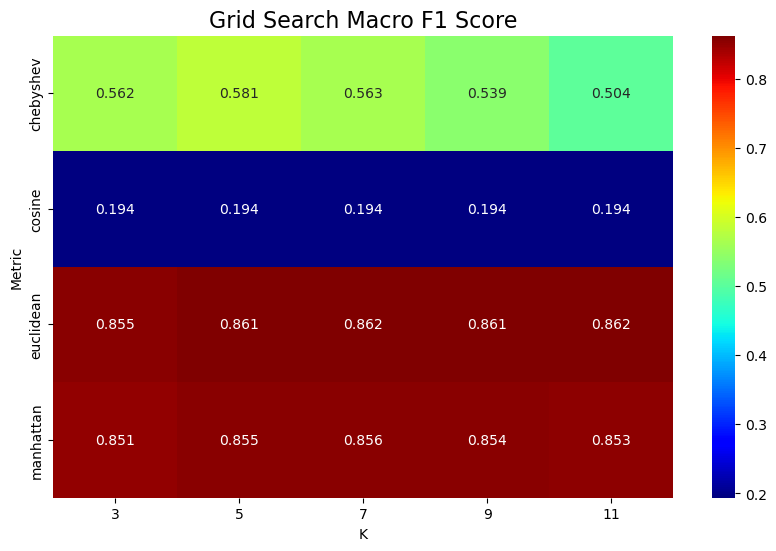

In [32]:
pivot_table = results_df.pivot(index='Metric', columns='K', values='Macro F1')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap = "jet", fmt=".3f")
plt.title('Grid Search Macro F1 Score', fontsize=16)
plt.show()

## We now hold the parameters for the final model!
### Let's test the model on the test dataset we saved from the beggining!

In [33]:
final_model = KNN_Image_Classifier(best_params["k"], best_params["metric"])
final_model.fit(X_train, y_train)

MAX_TESTS = len(X_test)
print("Training Final Model, this might take a while...")
y_pred = final_model.predict(X_test[:MAX_TESTS])

Training Final Model, this might take a while...


In [34]:
f1_scores = calculate_f1_scores(y_pred, y_test[:MAX_TESTS], classes)
macro_f1 = np.array(f1_scores).mean()
print(f"The final Model reached a Macro F1 score of {macro_f1 * 100:.2f}%")

The final Model reached a Macro F1 score of 88.58%


## Looks like our model does a nice job! 
### However we learn it also made a bunch of mistakes.
#### Let's observe some of these mistakes, in comparison to some successful classifications

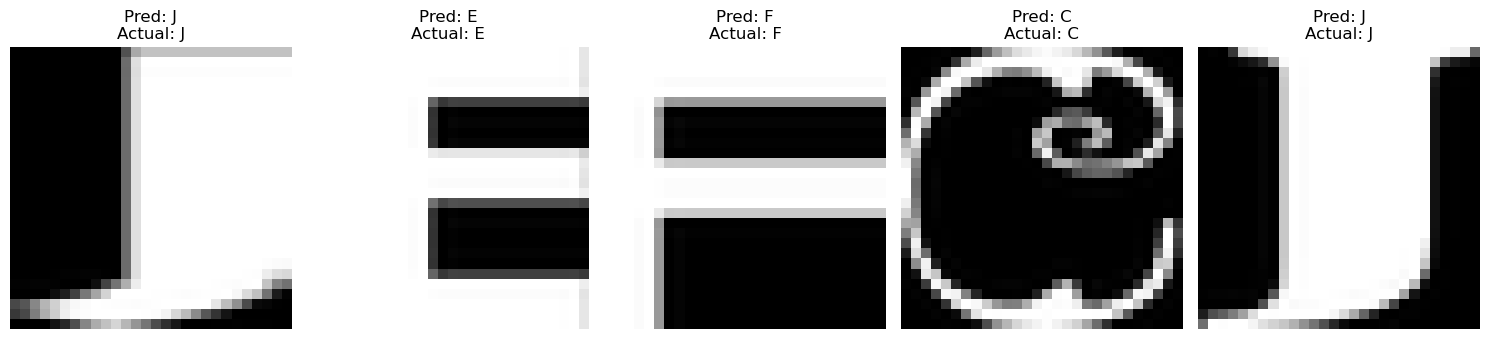

In [35]:
def show_predictions(samples, y_pred, y_actual, classes):
    num_samples = len(samples)
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)        
        img_display = samples[i].reshape(28, 28)
        plt.imshow(img_display, cmap = "gray")
        plt.title(f"Pred: {classes[y_pred[i]]}\nActual: {classes[y_actual[i]]}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

NUM_SAMPLES = 5
error_indexes = np.where(y_pred != y_test[:MAX_TESTS])[0]
show_predictions(X_test[:NUM_SAMPLES],y_pred[:NUM_SAMPLES], y_test[:NUM_SAMPLES], classes)

## Now let's see a few examples for when the model failed to classify the correct letter

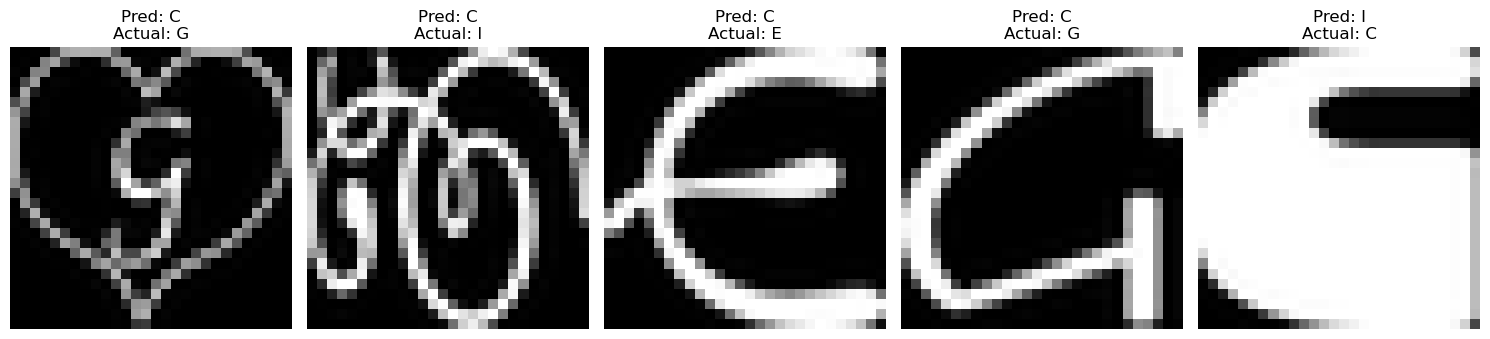

In [36]:
error_indexes = np.where(y_pred != y_test[:MAX_TESTS])[0]
samples_indexes = np.random.choice(error_indexes, min(NUM_SAMPLES, len(error_indexes)), replace = False)
X_samples = X_test[samples_indexes]      
y_samples_pred = y_pred[samples_indexes]
y_samples_actual = y_test[samples_indexes]

show_predictions(X_samples, y_samples_pred, y_samples_actual, classes)

### As we can see, some of these images may be confusing even for us as humans!
### And if that's the case then our model stood low chances against them, that explains the why it failed

***
# And Now for the moment of Truth!
### Will our model be able to predict the following image?! (Which is NOT included in the dataset!)
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/18/C_Programming_Language.svg/500px-C_Programming_Language.svg.png" width="200" height="200">

In [39]:
test_path = "C:/Users/liran/Downloads/moment_of_truth.jpg"

C_logo = Image.open(test_path).convert("L")
C_logo = C_logo.resize(IMG_SIZE)
C_logo = np.array(C_logo) / 255.0
C_logo = C_logo.reshape(1, -1)
result = final_model.predict(np.array(C_logo))
print(f"This letter is a {classes[result[0]]} !")

This letter is a C !


# And We Did It! 